# Ablation Study: Did HMM Conditioning Help?

Compares all synthetic variants vs real Astlingen 5-minute data:

| Version | Description | Resolution |
|---------|-------------|------------|
| **Real** | 10-year Astlingen gauged observations | 5 min |
| **v3** | Unconditional baseline (no HMM states) | 10 min → resampled |
| **v4** | Seasonal (4-class) conditional fine-tune | 10 min → resampled |
| **v5** | HMM-conditioned: 105,120-interval direct states | 5 min |
| **v6** | HMM-conditioned: 365-day climatological states | 5 min |

**Goal:** Determine whether HMM conditioning (v5/v6) improved realism over the unconditional (v3) and seasonal (v4) baselines.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import jensenshannon
import warnings
warnings.filterwarnings('ignore')
import os

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

COLORS = {
    'Real'           : '#1f77b4',
    'v3 (Uncond.)'   : '#9467bd',
    'v4 (Seasonal)'  : '#8c564b',
    'v5 (105k HMM)'  : '#e85d26',
    'v6 (365 HMM)'   : '#2ca02c',
}
ALPHAS = {
    'Real': 0.85, 'v3 (Uncond.)': 0.55,
    'v4 (Seasonal)': 0.55, 'v5 (105k HMM)': 0.55, 'v6 (365 HMM)': 0.55
}

BASE = os.path.abspath('..')   # project root when notebook is in data_analysis/
# BASE = os.path.abspath('.')  # use this if running from project root
print('Project root:', BASE)

Project root: /Users/tanyawarrier/Desktop/projects/ImagenFew


## 1. Load & Align All Datasets to 5-Minute Resolution

In [2]:
def load_synth(path, label):
    df = pd.read_csv(path, parse_dates=['date'])
    df['avg_rainfall'] = df['avg_rainfall'].clip(lower=0)
    df.loc[df['avg_rainfall'] < 0.005, 'avg_rainfall'] = 0.0
    freq = pd.infer_freq(df['date'].iloc[:50])
    print(f'  {label:22s}: {len(df):>10,} rows  |  inferred freq = {freq}')
    return df

def load_and_resample_10min(path, label):
    """Load 10-min CSV and upsample to 5-min via linear interpolation."""
    df = load_synth(path, label)
    df = df.set_index('date').resample('5T').interpolate('linear').reset_index()
    df['avg_rainfall'] = df['avg_rainfall'].clip(lower=0)
    df.loc[df['avg_rainfall'] < 0.005, 'avg_rainfall'] = 0.0
    print(f'    → after 5T resample: {len(df):,} rows')
    return df

# ── Real (5-min) ───────────────────────────────────────────────────────────
real_path = os.path.join(BASE, 'data', 'rainfall', 'train_dataset.csv')
df_real = pd.read_csv(real_path, parse_dates=['datetime'])
df_real = df_real[['datetime', 'avg_rainfall']].rename(columns={'datetime': 'date'})
print(f'  {"Real":22s}: {len(df_real):>10,} rows  |  freq = 5T')

# ── Synthetic variants ─────────────────────────────────────────────────────
print('\nLoading synthetic datasets:')
df_v3 = load_and_resample_10min(
    os.path.join(BASE, 'results', 'generated_data', 'rainfall_synthetic_10y_v3.csv'), 'v3 (Uncond.)')
df_v4 = load_and_resample_10min(
    os.path.join(BASE, 'results', 'generated_data', 'rainfall_synthetic_10y_v4.csv'), 'v4 (Seasonal)')
df_v5 = load_synth(
    os.path.join(BASE, 'results', 'generated_data', 'rainfall_synthetic_10y_v5.csv'), 'v5 (105k HMM)')
df_v6 = load_synth(
    os.path.join(BASE, 'results', 'generated_data', 'rainfall_synthetic_10y_v6.csv'), 'v6 (365 HMM)')

# Align all to same length
N = min(len(df_real), len(df_v3), len(df_v4), len(df_v5), len(df_v6))
real = df_real['avg_rainfall'].values[:N]
v3   = df_v3['avg_rainfall'].values[:N]
v4   = df_v4['avg_rainfall'].values[:N]
v5   = df_v5['avg_rainfall'].values[:N]
v6   = df_v6['avg_rainfall'].values[:N]

DATASETS = {
    'Real': real, 'v3 (Uncond.)': v3,
    'v4 (Seasonal)': v4, 'v5 (105k HMM)': v5, 'v6 (365 HMM)': v6
}
NZ = {l: a[a > 0] for l, a in DATASETS.items()}

print(f'\nAligned length: {N:,} timesteps ({N*5/60/24:.1f} days at 5-min resolution)')

  Real                  :    838,656 rows  |  freq = 5T

Loading synthetic datasets:
  v3 (Uncond.)          :    525,600 rows  |  inferred freq = 10min
    → after 5T resample: 1,051,199 rows
  v4 (Seasonal)         :    525,600 rows  |  inferred freq = 10min
    → after 5T resample: 1,051,199 rows
  v5 (105k HMM)         :  1,051,200 rows  |  inferred freq = 5min
  v6 (365 HMM)          :  1,051,200 rows  |  inferred freq = 5min

Aligned length: 838,656 timesteps (2912.0 days at 5-min resolution)


## 2. Basic Statistics Side-by-Side

In [3]:
def summary(arr, label):
    nz = arr[arr > 0]
    return {
        'Dataset'          : label,
        'Zero %'           : (arr == 0).mean() * 100,
        'Mean'             : arr.mean(),
        'Std'              : arr.std(),
        'Max'              : arr.max(),
        'P90'              : np.percentile(arr, 90),
        'P99'              : np.percentile(arr, 99),
        'P99.9'            : np.percentile(arr, 99.9),
        'Mean (wet only)'  : nz.mean() if len(nz) else 0,
        'Std (wet only)'   : nz.std() if len(nz) else 0,
        'Skewness'         : stats.skew(arr),
        'Kurtosis'         : stats.kurtosis(arr),
    }

df_stats = pd.DataFrame([summary(a, l) for l, a in DATASETS.items()]).set_index('Dataset').T
pd.set_option('display.float_format', '{:.5f}'.format)
display(df_stats)

Dataset,Real,v3 (Uncond.),v4 (Seasonal),v5 (105k HMM),v6 (365 HMM)
Zero %,90.91391,89.36000,90.03024,90.47822,91.27437
Mean,0.00684,0.01303,0.01337,0.00681,0.00686
Std,0.04694,0.08747,0.08986,0.04415,0.04603
Max,5.55500,5.20683,10.77006,3.90054,3.79208
P90,0.00000,0.00677,0.00000,0.00000,0.00000
P99,0.16000,0.30942,0.31904,0.15902,0.16707
P99.9,0.56500,1.14658,1.10956,0.57354,0.60907
Mean (wet only),0.07531,0.12249,0.13412,0.07148,0.07865
Std (wet only),0.13818,0.24186,0.25454,0.12589,0.13652
Skewness,25.32083,18.85622,23.01925,20.35458,18.97125


## 3. Intensity Distribution

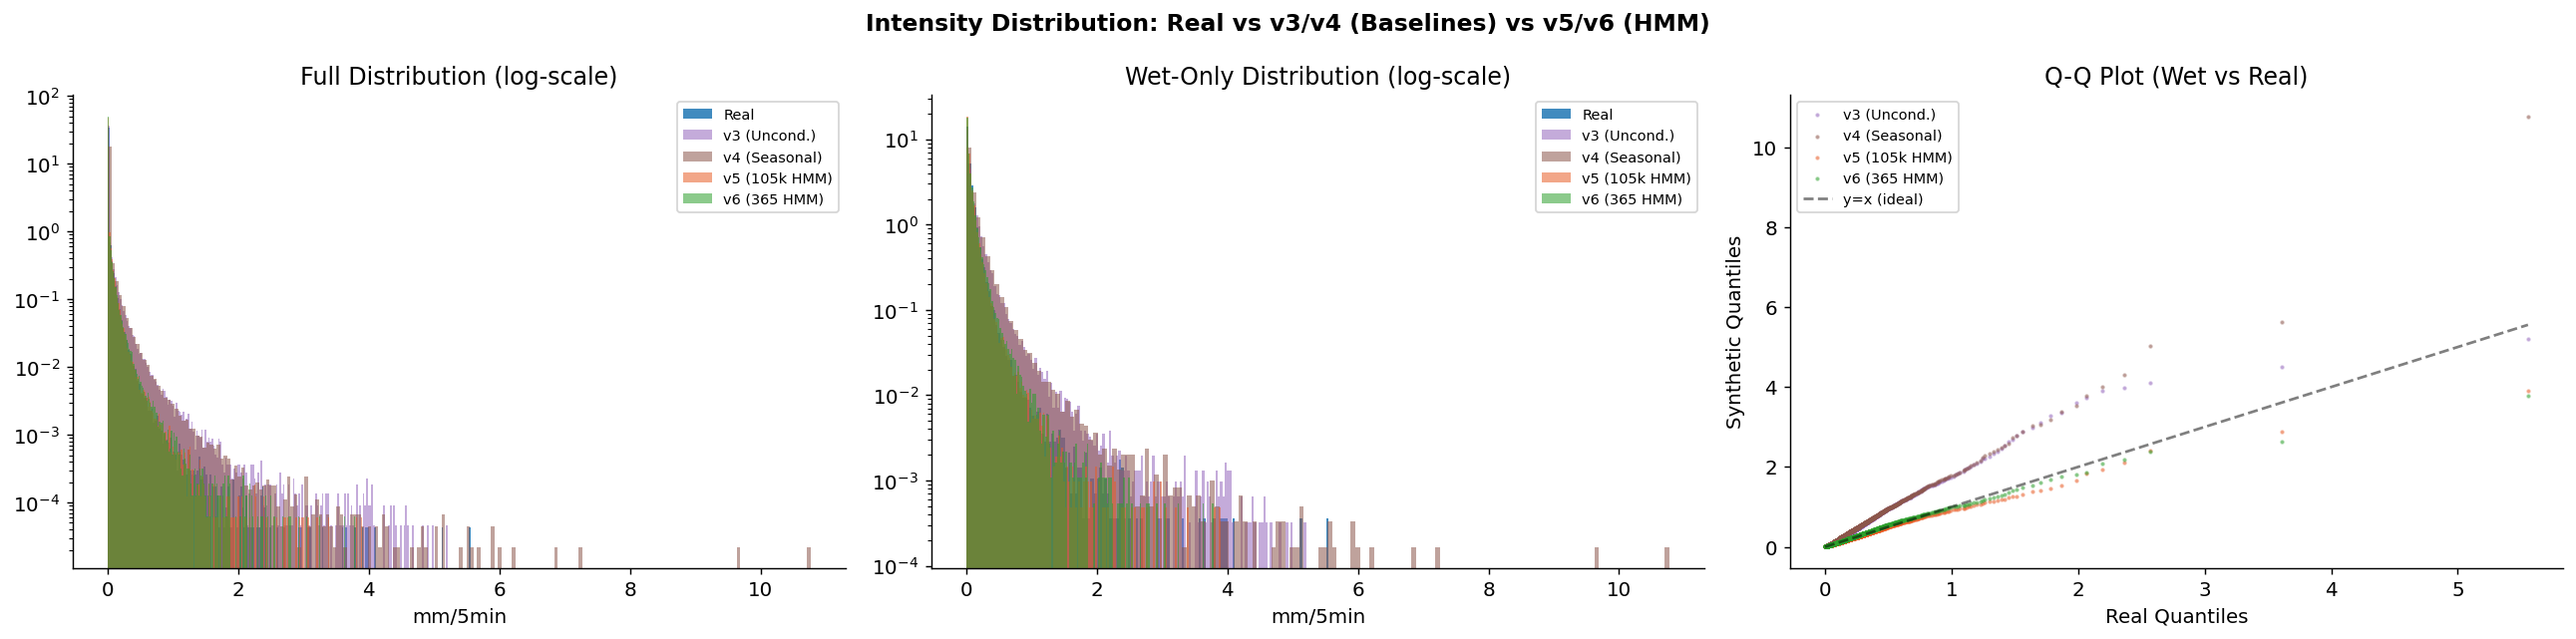


  Dataset                    KS stat        KS p         JSD
  ----------------------------------------------------------
  v3 (Uncond.)               0.10532    0.00e+00     0.10521
  v4 (Seasonal)              0.14639    0.00e+00     0.13366
  v5 (105k HMM)              0.08427   2.52e-241     0.02038
  v6 (365 HMM)               0.08829   1.27e-253     0.02368


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Intensity Distribution: Real vs v3/v4 (Baselines) vs v5/v6 (HMM)', fontsize=13, fontweight='bold')

# Full distribution
for label, arr in DATASETS.items():
    axes[0].hist(arr, bins=200, density=True, alpha=ALPHAS[label], label=label, color=COLORS[label])
axes[0].set_yscale('log'); axes[0].set_title('Full Distribution (log-scale)')
axes[0].set_xlabel('mm/5min'); axes[0].legend(fontsize=8)

# Wet-only
for label, arr in NZ.items():
    axes[1].hist(arr, bins=150, density=True, alpha=ALPHAS[label], label=label, color=COLORS[label])
axes[1].set_yscale('log'); axes[1].set_title('Wet-Only Distribution (log-scale)')
axes[1].set_xlabel('mm/5min'); axes[1].legend(fontsize=8)

# QQ plot against real
real_nz = NZ['Real']
n_qq = min(10000, min(len(v) for v in NZ.values()))
q_r = np.quantile(np.sort(real_nz), np.linspace(0, 1, n_qq))
for label in ['v3 (Uncond.)', 'v4 (Seasonal)', 'v5 (105k HMM)', 'v6 (365 HMM)']:
    q_s = np.quantile(np.sort(NZ[label]), np.linspace(0, 1, n_qq))
    axes[2].scatter(q_r, q_s, s=2, alpha=0.4, label=label, color=COLORS[label])
axes[2].plot([0, q_r.max()], [0, q_r.max()], 'k--', alpha=0.5, label='y=x (ideal)')
axes[2].set_title('Q-Q Plot (Wet vs Real)'); axes[2].set_xlabel('Real Quantiles')
axes[2].set_ylabel('Synthetic Quantiles'); axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

# KS + JSD
bins = np.linspace(0.001, max(v.max() for v in NZ.values()), 200)
hr, _ = np.histogram(real_nz, bins=bins, density=True); hr += 1e-12

print(f'\n  {"Dataset":22s}  {"KS stat":>10s}  {"KS p":>10s}  {"JSD":>10s}')
print('  ' + '-'*58)
for label in ['v3 (Uncond.)', 'v4 (Seasonal)', 'v5 (105k HMM)', 'v6 (365 HMM)']:
    ks, p = stats.ks_2samp(real_nz, NZ[label])
    hs, _ = np.histogram(NZ[label], bins=bins, density=True); hs += 1e-12
    jsd   = jensenshannon(hr, hs)
    print(f'  {label:22s}  {ks:>10.5f}  {p:>10.2e}  {jsd:>10.5f}')

## 4. Wet/Dry Spell Analysis

,Num wet spells,Mean wet (min),Median wet (min),Max wet (min),Num dry spells,Mean dry (hrs),Median dry (hrs),Max dry (hrs)
Dataset,,,,,,,,
Real,11604,32.83000,10.00000,1385,11604,5.48000,0.42000,801.58000
v3 (Uncond.),10604,42.08000,25.00000,520,10604,5.89000,1.42000,93.67000
v4 (Seasonal),11681,35.79000,25.00000,315,11682,5.39000,1.50000,83.00000
v5 (105k HMM),14873,26.85000,10.00000,315,14874,4.25000,1.08000,75.75000
v6 (365 HMM),13578,26.95000,15.00000,295,13579,4.70000,1.33000,73.08000


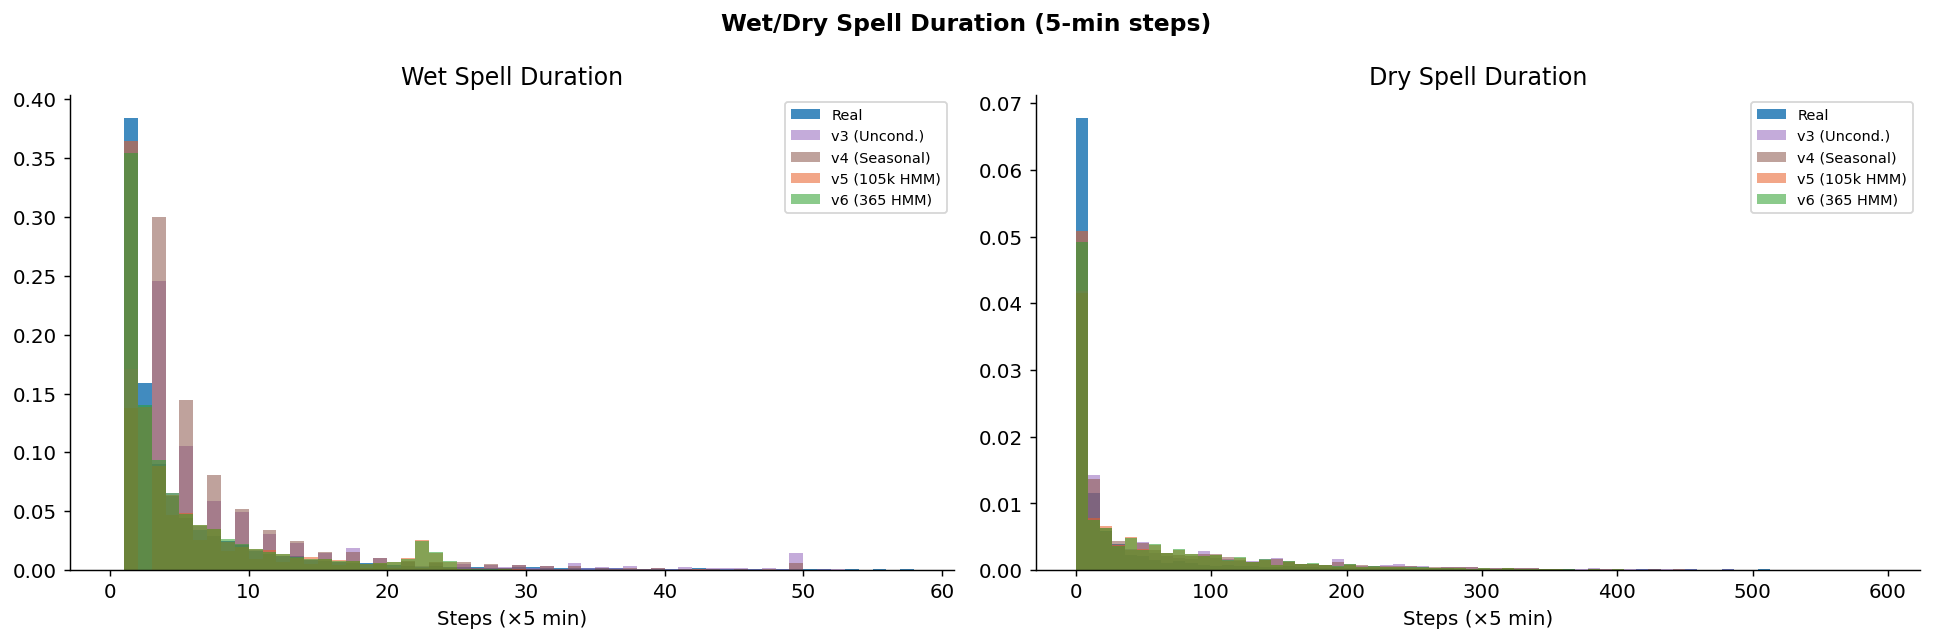


── KS Tests vs Real ──────────────────────────────────────────
  v3 (Uncond.)          : Wet KS=0.3656 (p=0.00e+00)   Dry KS=0.2565 (p=4.74e-322)
  v4 (Seasonal)         : Wet KS=0.3983 (p=0.00e+00)   Dry KS=0.2360 (p=9.23e-286)
  v5 (105k HMM)         : Wet KS=0.0465 (p=1.12e-12)   Dry KS=0.1702 (p=1.60e-165)
  v6 (365 HMM)          : Wet KS=0.0469 (p=2.15e-12)   Dry KS=0.1871 (p=3.52e-192)


In [5]:
def extract_spells(arr):
    is_wet  = (arr > 0).astype(int)
    changes = np.diff(is_wet, prepend=-1)
    starts  = np.where(changes != 0)[0]
    lengths = np.diff(np.append(starts, len(arr)))
    types   = is_wet[starts]
    return lengths[types == 1], lengths[types == 0]

SPELLS = {l: extract_spells(a) for l, a in DATASETS.items()}

spell_df = pd.DataFrame([
    {
        'Dataset'              : l,
        'Num wet spells'       : len(SPELLS[l][0]),
        'Mean wet (min)'       : SPELLS[l][0].mean() * 5,
        'Median wet (min)'     : np.median(SPELLS[l][0]) * 5,
        'Max wet (min)'        : SPELLS[l][0].max() * 5,
        'Num dry spells'       : len(SPELLS[l][1]),
        'Mean dry (hrs)'       : SPELLS[l][1].mean() * 5 / 60,
        'Median dry (hrs)'     : np.median(SPELLS[l][1]) * 5 / 60,
        'Max dry (hrs)'        : SPELLS[l][1].max() * 5 / 60,
    } for l in DATASETS
]).set_index('Dataset')
display(spell_df.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Wet/Dry Spell Duration (5-min steps)', fontsize=13, fontweight='bold')

all_wet = np.concatenate([SPELLS[l][0] for l in DATASETS])
all_dry = np.concatenate([SPELLS[l][1] for l in DATASETS])
max_wet = int(np.percentile(all_wet, 99.5) * 1.2)
max_dry = int(np.percentile(all_dry, 99) * 1.2)

for label, (wet, dry) in SPELLS.items():
    axes[0].hist(wet, bins=np.arange(0, max_wet+1), density=True,
                 alpha=ALPHAS[label], label=label, color=COLORS[label])
    axes[1].hist(dry, bins=np.arange(0, max_dry+1, max(1, max_dry//60)), density=True,
                 alpha=ALPHAS[label], label=label, color=COLORS[label])

axes[0].set_title('Wet Spell Duration'); axes[0].set_xlabel('Steps (×5 min)'); axes[0].legend(fontsize=8)
axes[1].set_title('Dry Spell Duration');  axes[1].set_xlabel('Steps (×5 min)'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print('\n── KS Tests vs Real ──────────────────────────────────────────')
for label in ['v3 (Uncond.)', 'v4 (Seasonal)', 'v5 (105k HMM)', 'v6 (365 HMM)']:
    kw, pw   = stats.ks_2samp(SPELLS['Real'][0], SPELLS[label][0])
    kd, pd_  = stats.ks_2samp(SPELLS['Real'][1], SPELLS[label][1])
    print(f'  {label:22s}: Wet KS={kw:.4f} (p={pw:.2e})   Dry KS={kd:.4f} (p={pd_:.2e})')

## 5. Temporal Autocorrelation

Computing ACFs (this takes ~30–60s)...
Done.


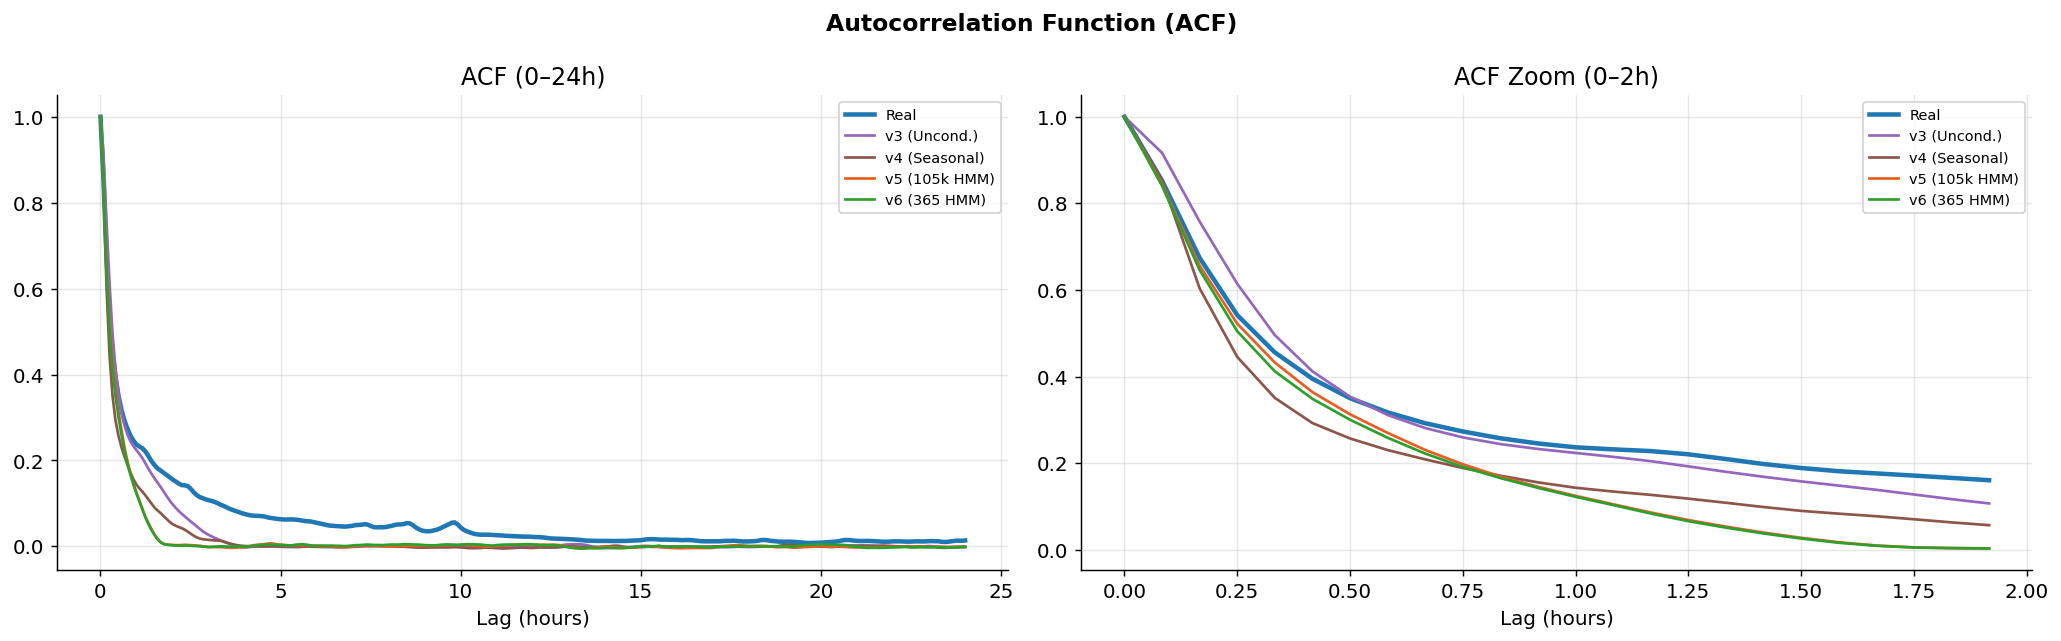


── ACF Error vs Real (lower = better) ───────────────────────
  Dataset                        MAE        RMSE
  ----------------------------------------------
  v3 (Uncond.)               0.03133     0.03885
  v4 (Seasonal)              0.03769     0.04833
  v5 (105k HMM)              0.03954     0.05500
  v6 (365 HMM)               0.03922     0.05507


In [6]:
def compute_acf(arr, max_lag=288):
    mean, var = arr.mean(), arr.var()
    n = len(arr)
    return np.array([np.mean((arr[:n-k]-mean)*(arr[k:]-mean))/var if var > 0 else 0
                     for k in range(max_lag + 1)])

MAX_LAG = 288
print('Computing ACFs (this takes ~30–60s)...')
ACFs = {l: compute_acf(a, MAX_LAG) for l, a in DATASETS.items()}
print('Done.')

lags_hours = np.arange(MAX_LAG + 1) * 5 / 60

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Autocorrelation Function (ACF)', fontsize=13, fontweight='bold')

for label, acf in ACFs.items():
    lw = 2.5 if label == 'Real' else 1.5
    axes[0].plot(lags_hours, acf, label=label, color=COLORS[label], linewidth=lw)
    axes[1].plot(lags_hours[:24], acf[:24], label=label, color=COLORS[label], linewidth=lw)

axes[0].set_title('ACF (0–24h)'); axes[0].set_xlabel('Lag (hours)'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_title('ACF Zoom (0–2h)'); axes[1].set_xlabel('Lag (hours)'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('\n── ACF Error vs Real (lower = better) ───────────────────────')
print(f'  {"Dataset":22s}  {"MAE":>10s}  {"RMSE":>10s}')
print('  ' + '-'*46)
for label in ['v3 (Uncond.)', 'v4 (Seasonal)', 'v5 (105k HMM)', 'v6 (365 HMM)']:
    mae  = np.abs(ACFs['Real'] - ACFs[label]).mean()
    rmse = np.sqrt(((ACFs['Real'] - ACFs[label])**2).mean())
    print(f'  {label:22s}  {mae:>10.5f}  {rmse:>10.5f}')

## 6. Extreme Value Analysis

,Real,v3 (Uncond.),v4 (Seasonal),v5 (105k HMM),v6 (365 HMM),v3 (Uncond.)/Real,v4 (Seasonal)/Real,v5 (105k HMM)/Real,v6 (365 HMM)/Real
Percentile,,,,,,,,,
90.00000,0.00000,0.00677,0.00000,0.00000,0.00000,inf,inf,inf,inf
95.00000,0.03000,0.05228,0.05652,0.03024,0.02740,1.74280,1.88392,1.00806,0.91325
99.00000,0.16000,0.30942,0.31904,0.15902,0.16707,1.93390,1.99401,0.99389,1.04417
99.50000,0.25000,0.48891,0.49105,0.24472,0.26613,1.95563,1.96420,0.97886,1.06453
99.90000,0.56500,1.14658,1.10956,0.57354,0.60907,2.02935,1.96383,1.01512,1.07801


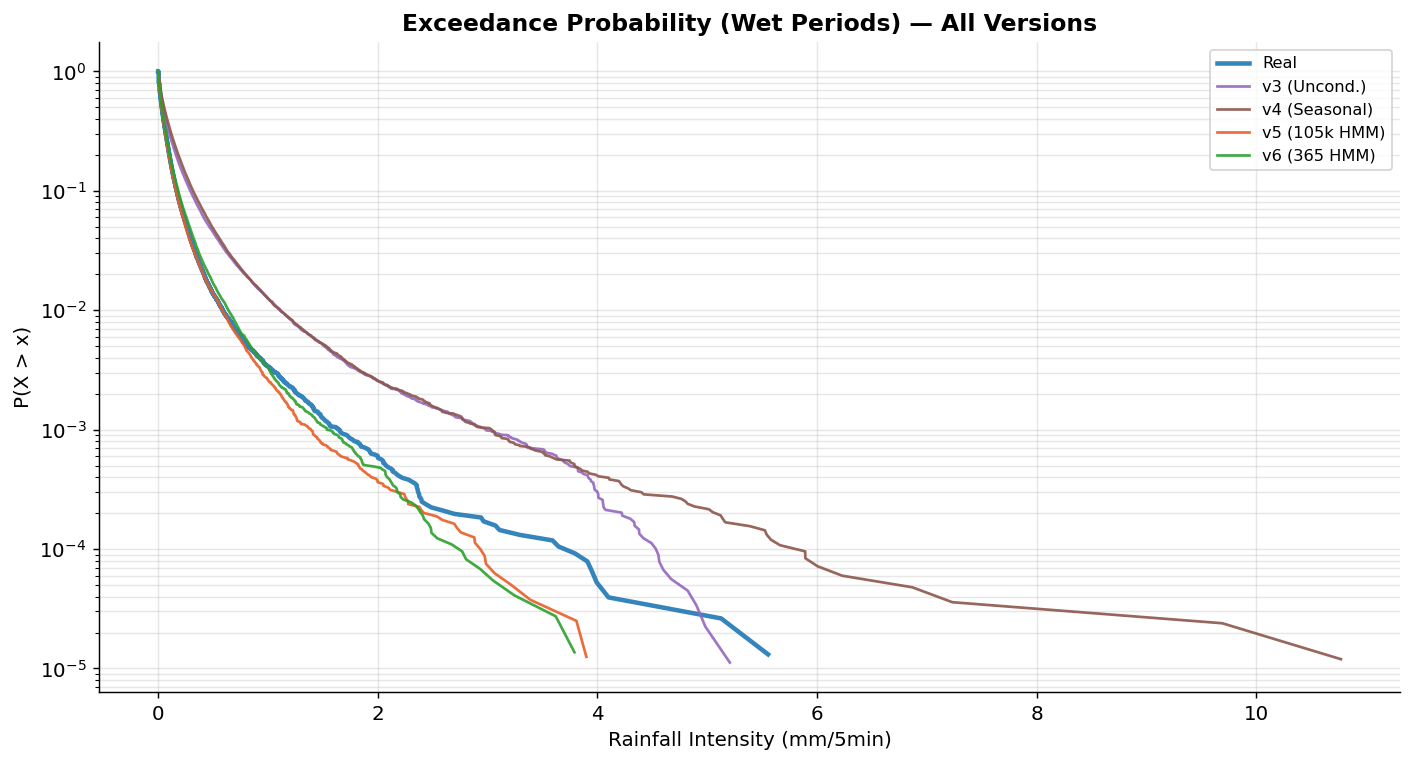

In [7]:
percentiles = [90, 95, 99, 99.5, 99.9]

rows = []
for p in percentiles:
    row = {'Percentile': p}
    for l, a in DATASETS.items():
        row[l] = np.percentile(a, p)
    real_val = row['Real']
    for l in ['v3 (Uncond.)', 'v4 (Seasonal)', 'v5 (105k HMM)', 'v6 (365 HMM)']:
        row[f'{l}/Real'] = row[l] / real_val if real_val > 0 else float('inf')
    rows.append(row)
display(pd.DataFrame(rows).set_index('Percentile').round(5))

# Exceedance probability
fig, ax = plt.subplots(figsize=(11, 6))
for label, arr in NZ.items():
    s = np.sort(arr)[::-1]
    p = np.arange(1, len(s)+1) / len(s)
    lw = 2.5 if label == 'Real' else 1.5
    ax.semilogy(s, p, label=label, color=COLORS[label], linewidth=lw, alpha=0.9)
ax.set_title('Exceedance Probability (Wet Periods) — All Versions', fontsize=13, fontweight='bold')
ax.set_xlabel('Rainfall Intensity (mm/5min)'); ax.set_ylabel('P(X > x)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()

## 7. Storm Event Analysis

,N storms,Mean dur (min),Median dur (min),Mean peak (mm),Max peak (mm),Mean vol (mm),Mean peak pos
Dataset,,,,,,,
Real,5387,63.26700,35.00000,0.15400,5.55500,1.04700,0.36700
v3 (Uncond.),8800,49.67600,25.00000,0.18200,5.20700,1.24100,0.40300
v4 (Seasonal),10075,40.69800,25.00000,0.21900,10.77000,1.11200,0.38700
v5 (105k HMM),7396,47.54000,35.00000,0.13900,3.90100,0.75600,0.39900
v6 (365 HMM),6872,46.98100,35.00000,0.15600,3.79200,0.82100,0.39400


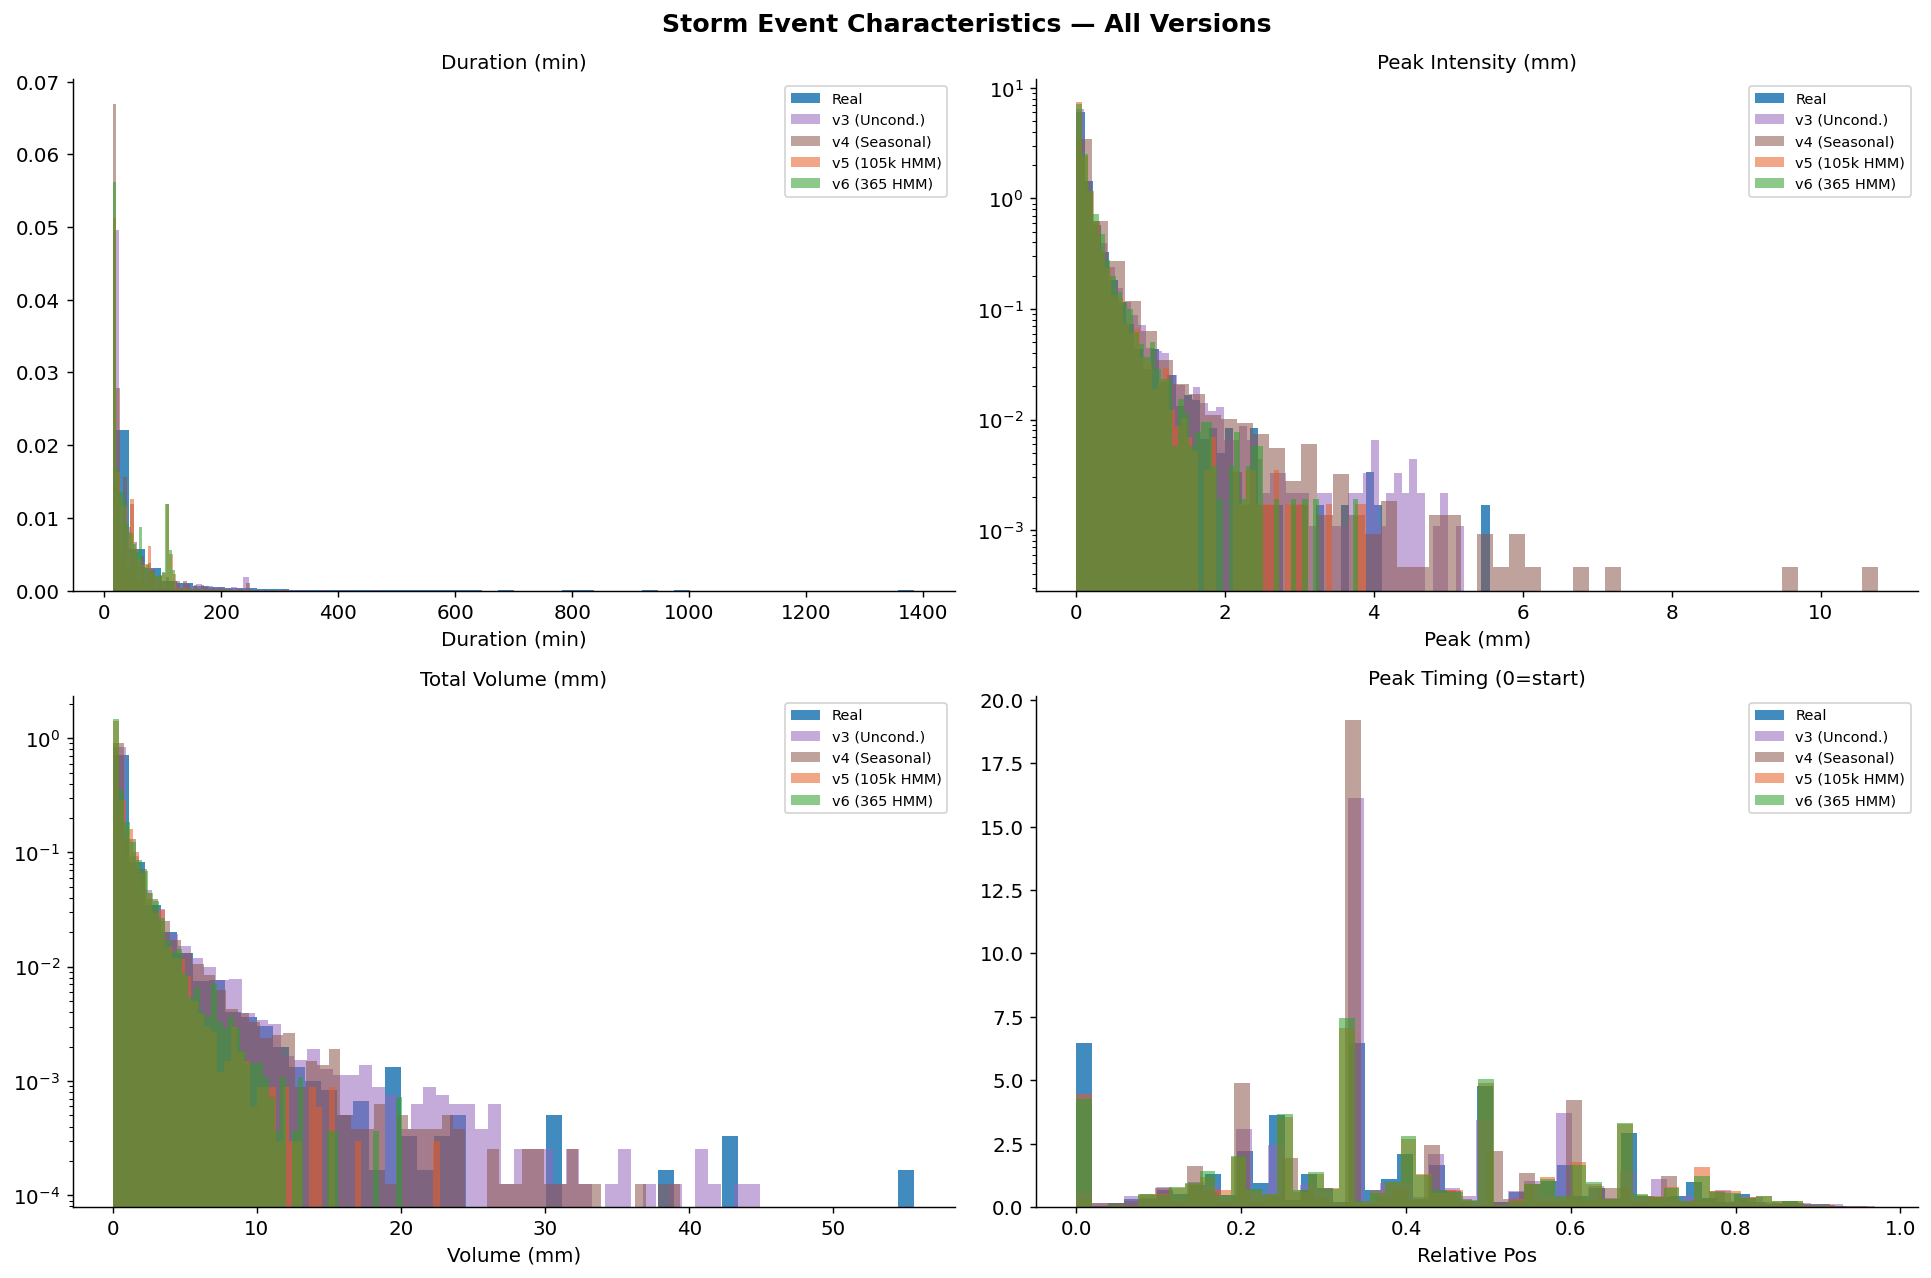


── Storm KS Tests vs Real ────────────────────────────────────
  v3 (Uncond.)          : Dur KS=0.1038  Peak KS=0.1202  Vol KS=0.1041
  v4 (Seasonal)         : Dur KS=0.1561  Peak KS=0.0967  Vol KS=0.0509
  v5 (105k HMM)         : Dur KS=0.1013  Peak KS=0.0516  Vol KS=0.0361
  v6 (365 HMM)          : Dur KS=0.1024  Peak KS=0.0691  Vol KS=0.0506


In [8]:
def extract_storms(arr, min_dur=3):
    is_wet  = (arr > 0).astype(int)
    changes = np.diff(is_wet, prepend=-1)
    starts  = np.where(changes != 0)[0]
    lengths = np.diff(np.append(starts, len(arr)))
    types   = is_wet[starts]
    return [arr[s:s+l] for s, l, t in zip(starts, lengths, types) if t == 1 and l >= min_dur]

STORMS = {l: extract_storms(a) for l, a in DATASETS.items()}

storm_df = pd.DataFrame([
    {
        'Dataset'           : l,
        'N storms'          : len(STORMS[l]),
        'Mean dur (min)'    : np.mean([len(s)*5 for s in STORMS[l]]),
        'Median dur (min)'  : np.median([len(s)*5 for s in STORMS[l]]),
        'Mean peak (mm)'    : np.mean([s.max() for s in STORMS[l]]),
        'Max peak (mm)'     : np.max([s.max() for s in STORMS[l]]),
        'Mean vol (mm)'     : np.mean([s.sum() for s in STORMS[l]]),
        'Mean peak pos'     : np.mean([np.argmax(s)/len(s) for s in STORMS[l]]),
    } for l in DATASETS
]).set_index('Dataset')
display(storm_df.round(3))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Storm Event Characteristics — All Versions', fontsize=14, fontweight='bold')

plots = [
    ('Duration (min)',         (0,0), lambda ss: np.array([len(s)*5 for s in ss]),           'Duration (min)', False),
    ('Peak Intensity (mm)',    (0,1), lambda ss: np.array([s.max() for s in ss]),             'Peak (mm)',       True),
    ('Total Volume (mm)',      (1,0), lambda ss: np.array([s.sum() for s in ss]),             'Volume (mm)',     True),
    ('Peak Timing (0=start)', (1,1), lambda ss: np.array([np.argmax(s)/len(s) for s in ss]),'Relative Pos',    False),
]
for title, idx, fn, xlabel, log_y in plots:
    ax = axes[idx]
    for label, storms in STORMS.items():
        vals = fn(storms)
        ax.hist(vals, bins=50, density=True, alpha=ALPHAS[label], label=label, color=COLORS[label])
    ax.set_title(title, fontsize=11); ax.set_xlabel(xlabel); ax.legend(fontsize=8)
    if log_y: ax.set_yscale('log')

plt.tight_layout(); plt.show()

print('\n── Storm KS Tests vs Real ────────────────────────────────────')
dur_r  = np.array([len(s)*5 for s in STORMS['Real']])
peak_r = np.array([s.max()  for s in STORMS['Real']])
vol_r  = np.array([s.sum()  for s in STORMS['Real']])
for label in ['v3 (Uncond.)', 'v4 (Seasonal)', 'v5 (105k HMM)', 'v6 (365 HMM)']:
    dur_s  = np.array([len(s)*5 for s in STORMS[label]])
    peak_s = np.array([s.max()  for s in STORMS[label]])
    vol_s  = np.array([s.sum()  for s in STORMS[label]])
    kd, _  = stats.ks_2samp(dur_r,  dur_s)
    kp, _  = stats.ks_2samp(peak_r, peak_s)
    kv, _  = stats.ks_2samp(vol_r,  vol_s)
    print(f'  {label:22s}: Dur KS={kd:.4f}  Peak KS={kp:.4f}  Vol KS={kv:.4f}')

## 8. Sample Timeseries Visual

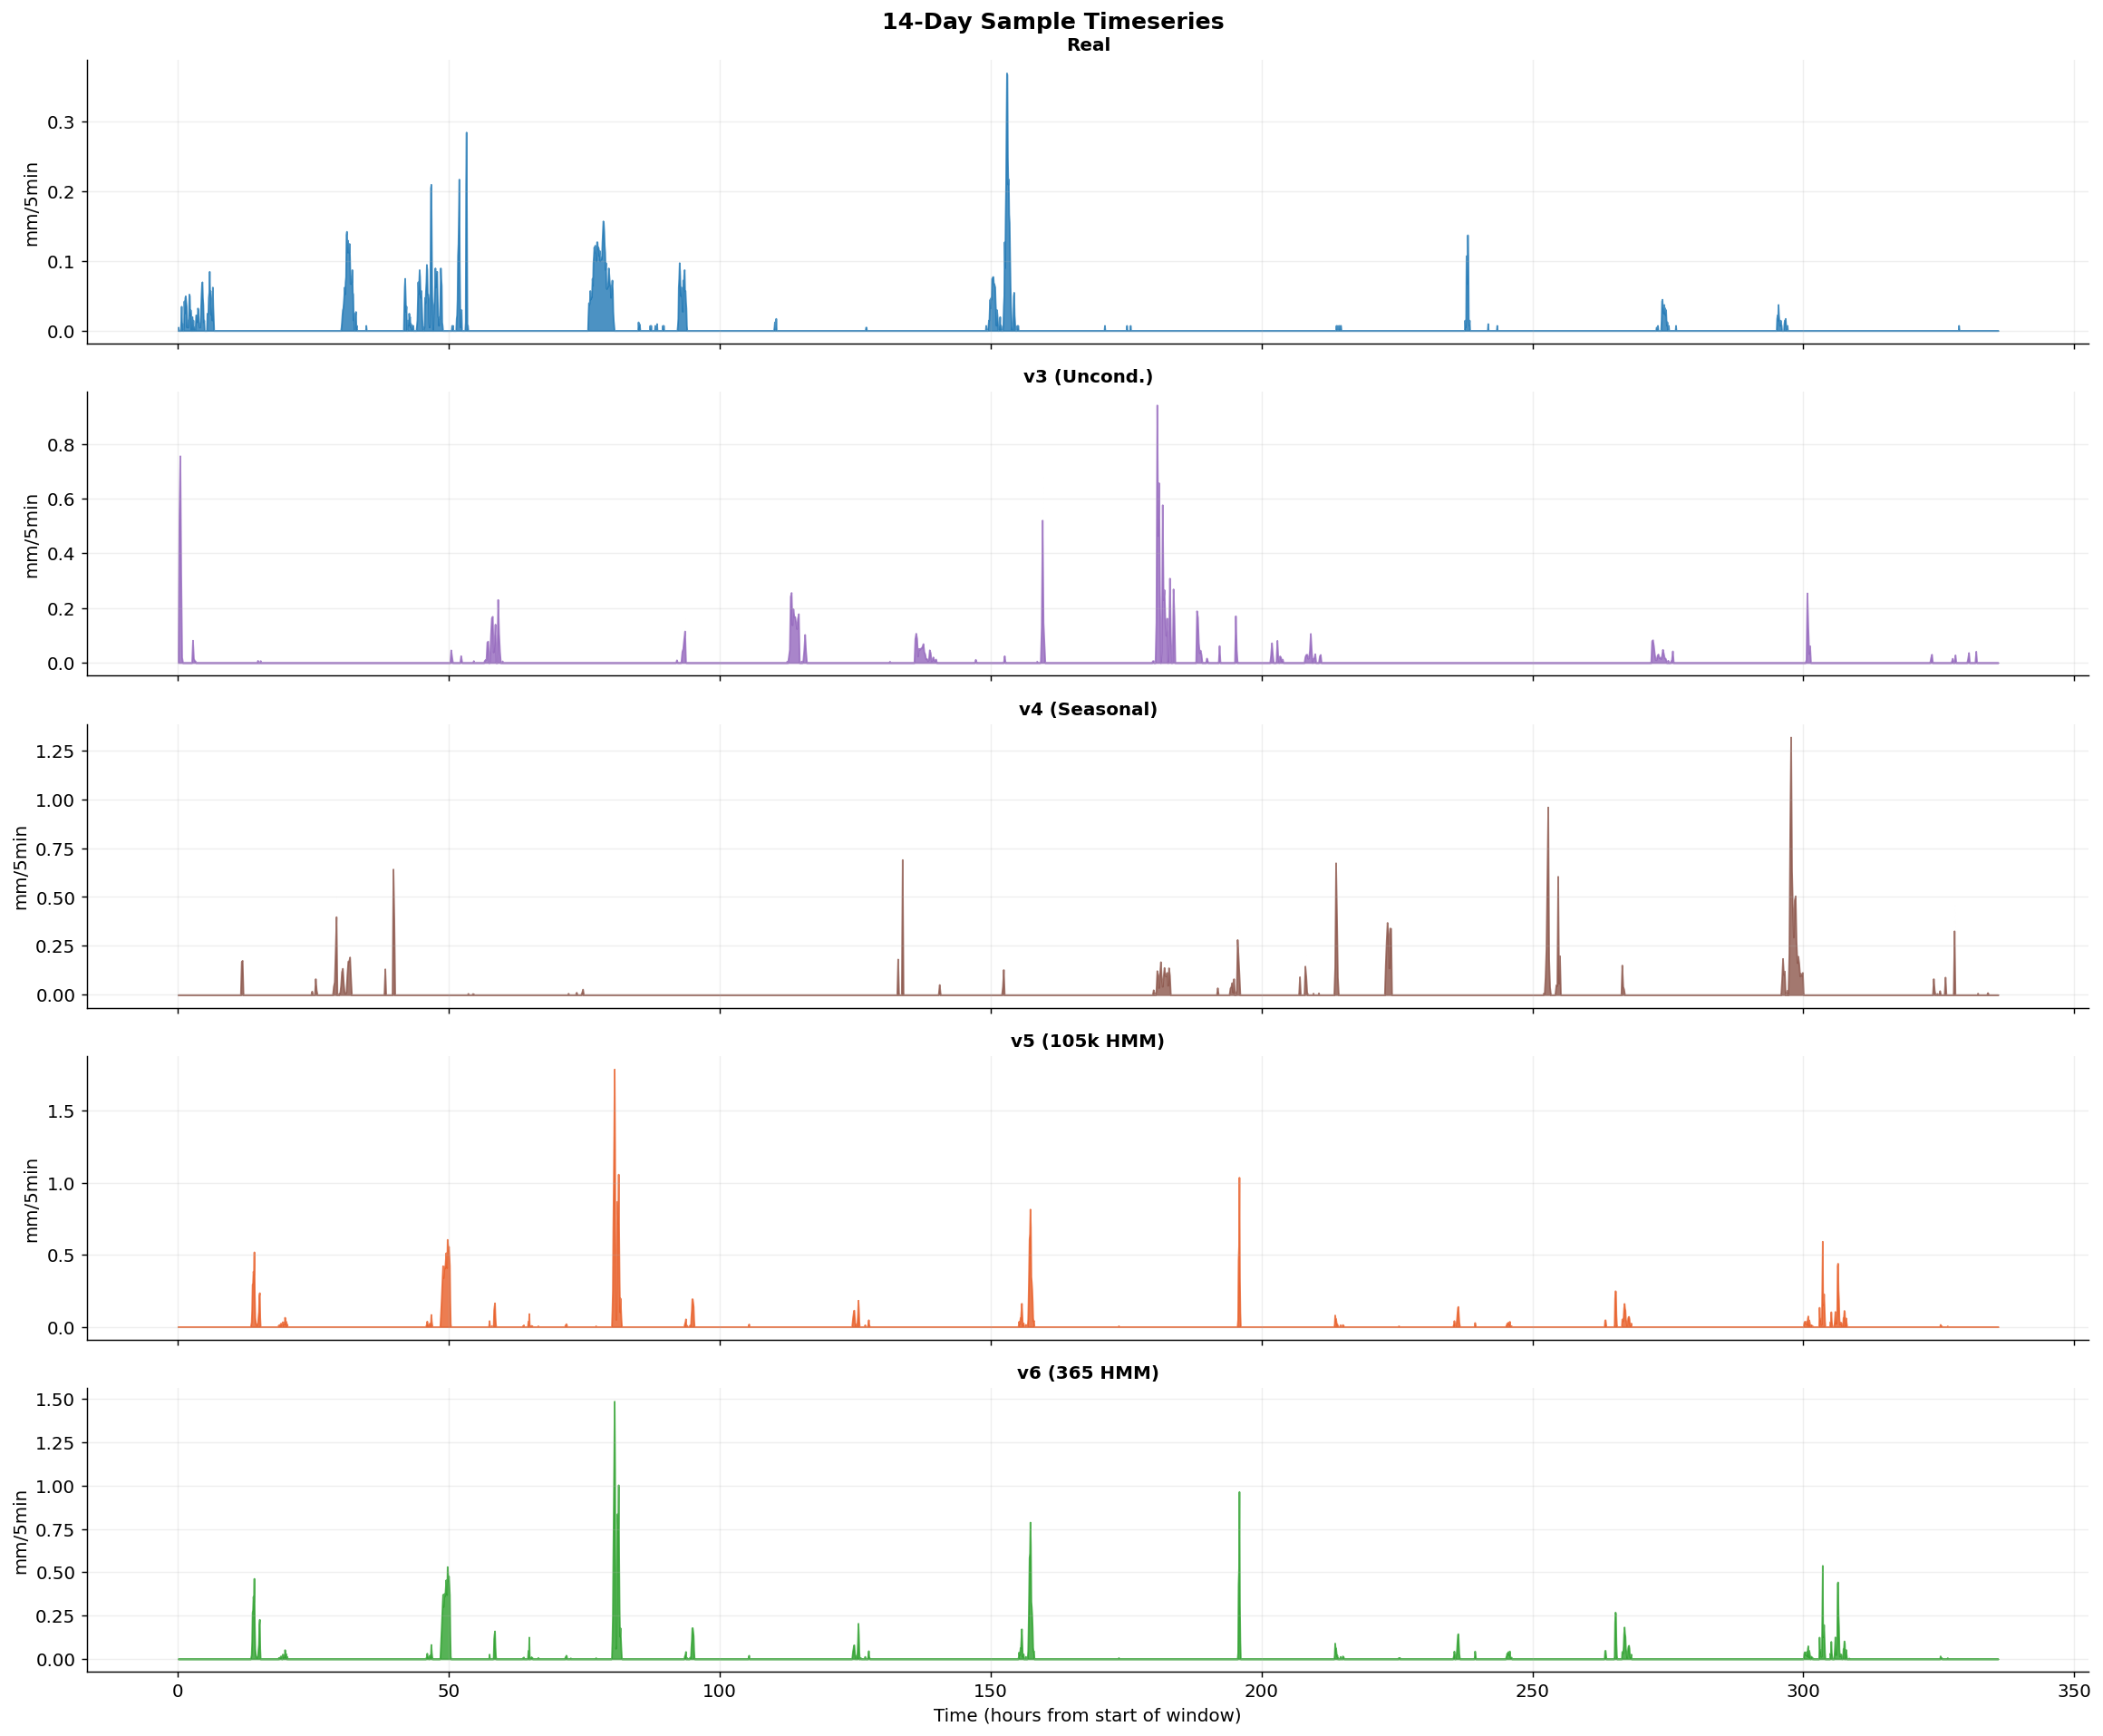

In [9]:
WINDOW = 288 * 14

def find_rainy(arr, window, min_total=5):
    for start in range(0, len(arr)-window, 288):
        if arr[start:start+window].sum() > min_total:
            return arr[start:start+window]
    return arr[:window]

hours = np.arange(WINDOW) * 5 / 60
fig, axes = plt.subplots(5, 1, figsize=(18, 15), sharex=True)
fig.suptitle('14-Day Sample Timeseries', fontsize=14, fontweight='bold')

for ax, (label, arr) in zip(axes, DATASETS.items()):
    w = find_rainy(arr, WINDOW)
    ax.fill_between(hours, w, alpha=0.8, color=COLORS[label])
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('mm/5min'); ax.grid(alpha=0.2)

axes[-1].set_xlabel('Time (hours from start of window)')
plt.tight_layout(); plt.show()

## 9. RL-Fitness Scorecard — Full Ablation

In [10]:
def compute_scores(label, synth, synth_nz, acf_s):
    real_nz = NZ['Real']
    scores  = {}

    # Wet/dry ratio
    err = abs((real > 0).mean() - (synth > 0).mean()) / (real > 0).mean()
    scores['Wet/Dry Ratio']        = max(0, 1 - err * 5)

    # Mean intensity (wet)
    err = abs(real_nz.mean() - synth_nz.mean()) / real_nz.mean()
    scores['Mean Intensity (wet)'] = max(0, 1 - err * 2)

    # JSD (wet-only)
    bins = np.linspace(0.001, max(real_nz.max(), synth_nz.max()), 200)
    hr, _ = np.histogram(real_nz,  bins=bins, density=True); hr += 1e-12
    hs, _ = np.histogram(synth_nz, bins=bins, density=True); hs += 1e-12
    scores['Distribution (JSD)']   = max(0, 1 - jensenshannon(hr, hs) * 4)

    # ACF
    scores['Autocorrelation']      = max(0, 1 - np.abs(ACFs['Real'] - acf_s).mean() * 10)

    # Storm duration
    dur_r = np.array([len(s) for s in STORMS['Real']])
    dur_s = np.array([len(s) for s in STORMS[label]])
    err   = abs(dur_r.mean() - dur_s.mean()) / dur_r.mean()
    scores['Storm Duration']       = max(0, 1 - err * 3)

    # P99
    ratio = np.percentile(synth_nz, 99) / np.percentile(real_nz, 99)
    scores['Extreme Values (P99)'] = max(0, 1 - abs(1 - ratio) * 3)

    # Storm count
    ratio = len(STORMS[label]) / len(STORMS['Real'])
    scores['Storm Count']          = max(0, 1 - abs(1 - ratio) * 2)

    # Peak timing
    pp_r = np.mean([np.argmax(s)/len(s) for s in STORMS['Real']])
    pp_s = np.mean([np.argmax(s)/len(s) for s in STORMS[label]])
    scores['Peak Timing']          = max(0, 1 - abs(pp_r - pp_s) * 5)

    return scores

SYNTH_LABELS = ['v3 (Uncond.)', 'v4 (Seasonal)', 'v5 (105k HMM)', 'v6 (365 HMM)']
SCORES = {l: compute_scores(l, DATASETS[l], NZ[l], ACFs[l]) for l in SYNTH_LABELS}

dims = list(next(iter(SCORES.values())).keys())
print(f'  {"Dimension":30s}  {"v3":>8s}  {"v4":>8s}  {"v5":>8s}  {"v6":>8s}')
print('  ' + '-'*68)
for d in dims:
    vals = [SCORES[l][d] for l in SYNTH_LABELS]
    best = max(vals)
    row  = '  ' + f'{d:30s}'
    for l, v in zip(SYNTH_LABELS, vals):
        flag = ' ◀' if v == best else '  '
        row += f'  {v:>6.3f}{flag}'
    print(row)

ov = {l: np.mean(list(s.values())) for l, s in SCORES.items()}
print('  ' + '-'*68)
print(f'  {"OVERALL":30s}  ' + '  '.join(f'{ov[l]:>8.3f}' for l in SYNTH_LABELS))
print()
for label, score in ov.items():
    verdict = '✅ FIT' if score >= 0.7 else ('⚠️  CONDITIONAL' if score >= 0.5 else '❌ NOT FIT')
    print(f'  {label}: {verdict} (score={score:.3f})')

  Dimension                             v3        v4        v5        v6
  --------------------------------------------------------------------
  Wet/Dry Ratio                    0.145     0.514     0.760     0.802 ◀
  Mean Intensity (wet)             0.000     0.000     0.898     0.911 ◀
  Distribution (JSD)               0.572     0.465     0.883     0.885 ◀
  Autocorrelation                  0.687 ◀   0.623     0.605     0.608  
  Storm Duration                   0.356 ◀   0.000     0.254     0.228  
  Extreme Values (P99)             0.000     0.000     0.972 ◀   0.736  
  Storm Count                      0.000     0.000     0.254     0.449 ◀
  Peak Timing                      0.821     0.901 ◀   0.838     0.864  
  --------------------------------------------------------------------
  OVERALL                            0.323     0.313     0.683     0.685

  v3 (Uncond.): ❌ NOT FIT (score=0.323)
  v4 (Seasonal): ❌ NOT FIT (score=0.313)
  v5 (105k HMM): ⚠️  CONDITIONAL (score=0.683)

## 10. Visual Scorecard: Improvement Over Baseline (v3)

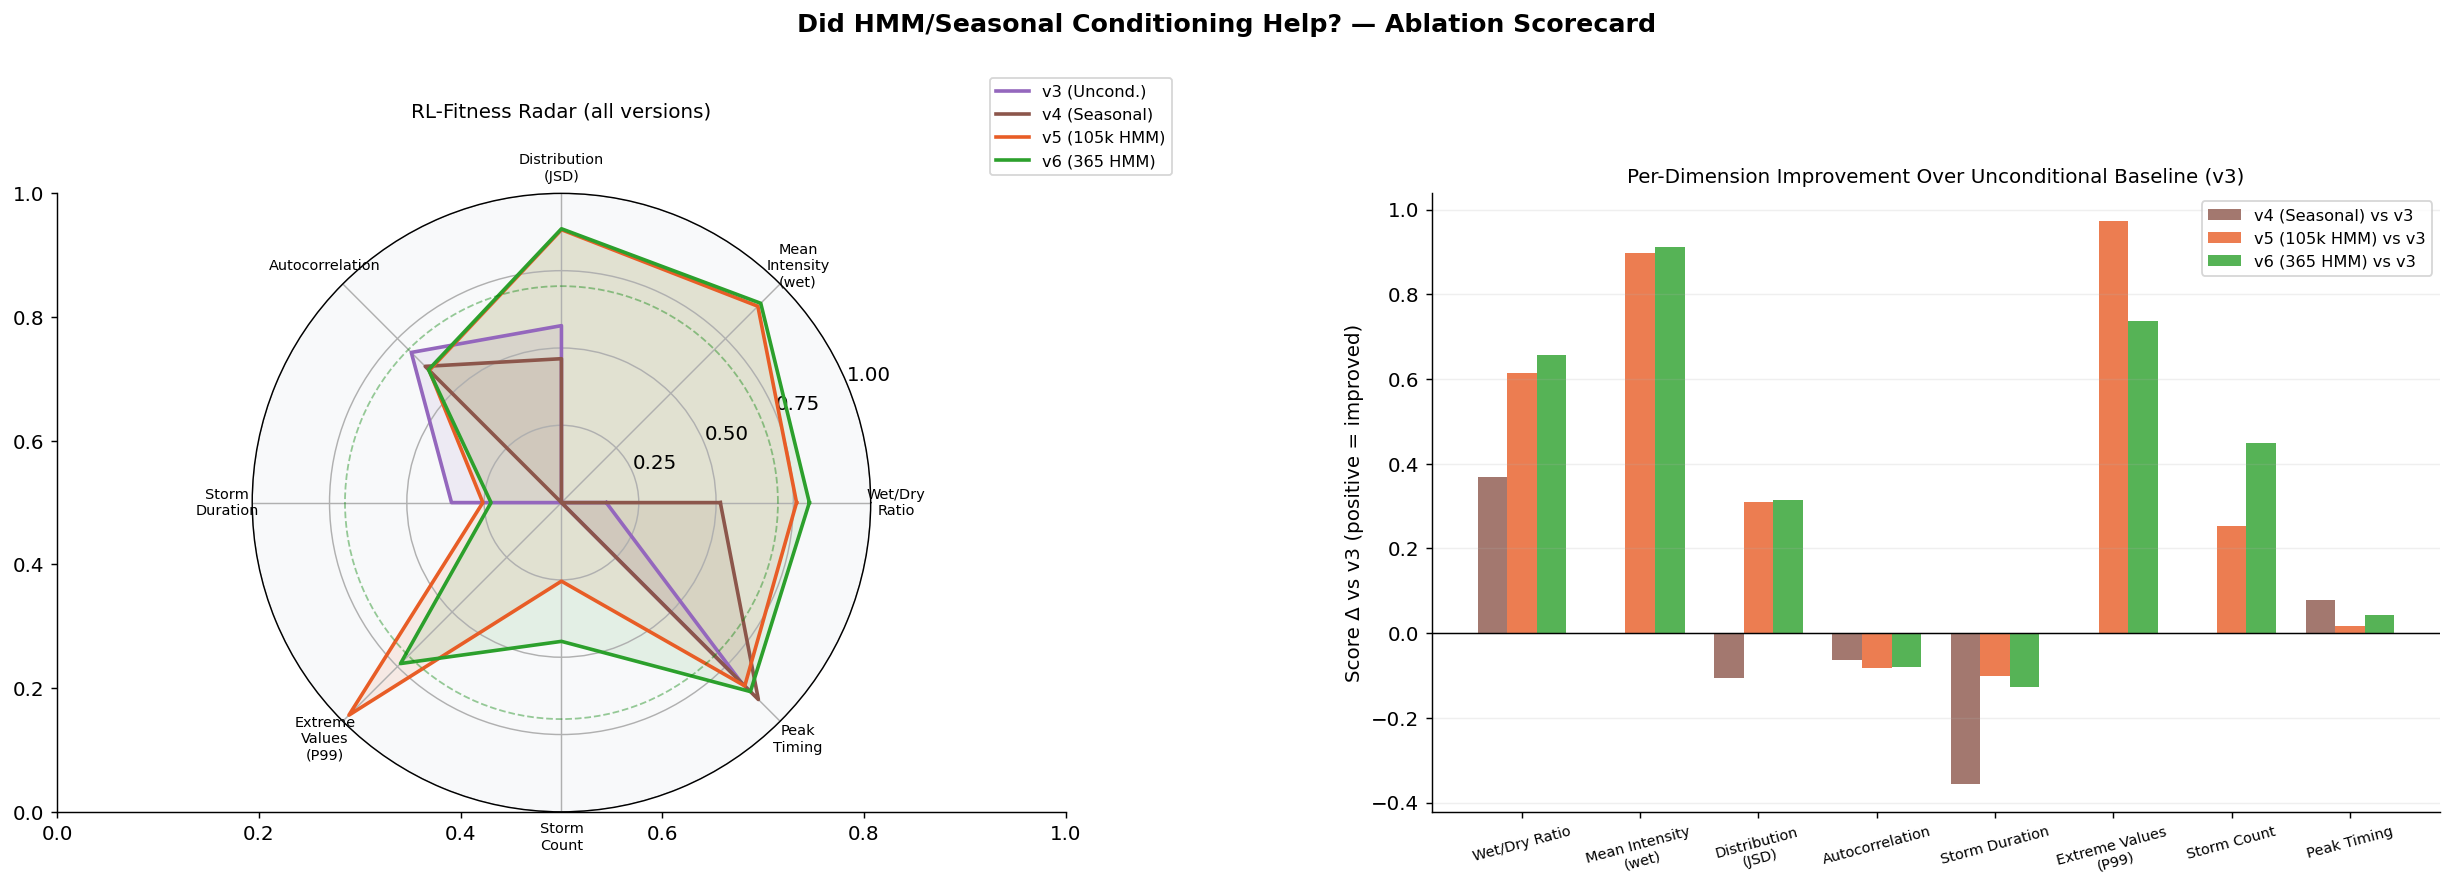


── Improvement Over v3 Summary ──────────────────────────────────
  v4 (Seasonal)         : improved in 2/8 dims  |  overall Δ = -0.010 ↓
  v5 (105k HMM)         : improved in 6/8 dims  |  overall Δ = +0.360 ↑
  v6 (365 HMM)          : improved in 6/8 dims  |  overall Δ = +0.363 ↑

  Overall scores: v3= 0.323  v4= 0.313  v5= 0.683  v6= 0.685


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(19, 7))
fig.suptitle('Did HMM/Seasonal Conditioning Help? — Ablation Scorecard', fontsize=14, fontweight='bold')

# ── Left: Radar chart ──────────────────────────────────────────────────────
ax = plt.subplot(121, polar=True)
ax.set_facecolor('#f8f9fa')
N_dims = len(dims)
angles = np.linspace(0, 2*np.pi, N_dims, endpoint=False).tolist() + [0]

for label in SYNTH_LABELS:
    vals = [SCORES[label][d] for d in dims] + [SCORES[label][dims[0]]]
    ax.plot(angles, vals, color=COLORS[label], linewidth=2, label=label)
    ax.fill(angles, vals, color=COLORS[label], alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([d.replace(' ', '\n') for d in dims], size=8)
ax.set_ylim(0, 1); ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.axhline(0.7, color='green', lw=1, ls='--', alpha=0.4)
ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1.2), fontsize=9)
ax.set_title('RL-Fitness Radar (all versions)', fontsize=11, pad=20)

# ── Right: Bar chart — dimension-wise improvement over v3 ──────────────────
ax2 = axes[1]
x   = np.arange(len(dims))
w   = 0.25
offsets = [-w, 0, w]
compare_labels = ['v4 (Seasonal)', 'v5 (105k HMM)', 'v6 (365 HMM)']

for offset, label in zip(offsets, compare_labels):
    imp = [SCORES[label][d] - SCORES['v3 (Uncond.)'][d] for d in dims]
    ax2.bar(x + offset, imp, w, label=f'{label} vs v3', color=COLORS[label], alpha=0.8)

ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels([d.replace(' (', '\n(') for d in dims], fontsize=8, rotation=15)
ax2.set_ylabel('Score Δ vs v3 (positive = improved)')
ax2.set_title('Per-Dimension Improvement Over Unconditional Baseline (v3)', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(alpha=0.2, axis='y')

plt.tight_layout(); plt.show()

# Summary
print('\n── Improvement Over v3 Summary ──────────────────────────────────')
for label in compare_labels:
    n_imp = sum(1 for d in dims if SCORES[label][d] > SCORES['v3 (Uncond.)'][d])
    delta = ov[label] - ov['v3 (Uncond.)']
    trend = '↑' if delta > 0 else '↓'
    print(f'  {label:22s}: improved in {n_imp}/{len(dims)} dims  |  overall Δ = {delta:+.3f} {trend}')
print(f'\n  Overall scores: v3={ov["v3 (Uncond.)"]: .3f}  v4={ov["v4 (Seasonal)"]: .3f}  v5={ov["v5 (105k HMM)"]: .3f}  v6={ov["v6 (365 HMM)"]: .3f}')